In [16]:
# LangGraph pipeline for GenAI Customer Insight Generator

from langgraph.graph import StateGraph, END
from typing import TypedDict, List, Dict
import pandas as pd
import numpy as np
from langchain_core.runnables import Runnable
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# -------------------------
# 0. Setup LLM
# -------------------------
load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(groq_api_key=groq_api_key, model="llama-3.1-8b-instant", temperature=0)


In [18]:
# Load Data
features_df = pd.read_csv("./customer_features_long_format.csv")
scores_df = pd.read_csv("./customer_scores_long_format.csv")


In [39]:
# Reshape long format to wide for easier analysis
def reshape_data():
    features_pivot = features_df.pivot(index="customer_id", columns="feature_name", values="feature_value")
    scores_pivot = scores_df.pivot(index="customer_id", columns="score_name", values="score_value")
    combined = pd.concat([features_pivot, scores_pivot], axis=1).reset_index()
    return combined

In [40]:
# LangGraph state
class State(TypedDict):
    customer_id: str
    customer_data: Dict[str, float]
    insights: str

In [41]:
# Node: Extract customer data
def fetch_customer_data(input: State) -> State:
    customer_id = input['customer_id']
    combined_df = reshape_data()
    row = combined_df[combined_df.customer_id == customer_id].to_dict(orient="records")[0]
    return {"customer_id": customer_id, "customer_data": row, "insights": ""}



In [42]:
# Node: Generate Insight from KPIs and SHAPs
class GenInsightNode(Runnable):
    def invoke(self, input: State, config=None) -> State:
        customer_data = input["customer_data"]
        customer_id = input["customer_id"]

        # Separate KPIs and SHAPs
        kpis = {k: v for k, v in customer_data.items() if k in ["rsrp", "sinr"]}
        shap_values = {k: v for k, v in customer_data.items() if k.startswith("shap_")}
        scores = {k: v for k, v in customer_data.items() if k in ["main_score", "capacity_subscore"]}

        prompt = f"""
        Given the following KPI values, SHAP values, and scores for customer {customer_id}, provide a natural language summary explaining why the customer's experience score is the way it is.

        KPIs:
        {kpis}

        SHAP Values:
        {shap_values}

        Scores:
        {scores}

        Explain what factors are contributing most to the low or high score and if the SHAP values align with the KPI values. If any discrepancy exists, point it out.
        """
        response = llm.invoke([HumanMessage(content=prompt)])
        return {**input, "insights": response.content}


In [43]:
# Node: Final Output
def final_output(input: State) -> State:
    print("\n=== CUSTOMER INSIGHT REPORT ===")
    print(f"Customer ID: {input['customer_id']}")
    print(input['insights'])
    return input

# Batch processing function
def analyze_batch(customer_ids: List[str]):
    print("\n=== BATCH CUSTOMER INSIGHT REPORTS ===")
    for cid in customer_ids:
        initial_state = {"customer_id": cid, "customer_data": {}, "insights": ""}
        _ = graph.invoke(initial_state)


def generate_visualizations():
    combined = reshape_data()
    score_col = "main_score"
    output_dir = "./visualisations/feature_vs_score_plots"
    os.makedirs(output_dir, exist_ok=True)

    for feature in combined.columns:
        if feature not in ["customer_id", "main_score", "capacity_subscore"] and not feature.startswith("shap_"):
            plt.figure(figsize=(10, 6))
            try:
                sns.boxplot(data=combined, x=pd.qcut(combined[score_col], 5), y=feature)
                plt.title(f"{feature.upper()} Distribution Across {score_col.replace('_', ' ').title()} Quintiles")
                plt.xlabel(f"{score_col.replace('_', ' ').title()} Quintile")
                plt.ylabel(feature.upper())
                plt.tight_layout()
                file_path = os.path.join(output_dir, f"{feature}_vs_{score_col}.png")
                plt.savefig(file_path)
                plt.close()
                print(f"Saved: {file_path}")
            except Exception as e:
                print(f"Skipped {feature} due to error: {e}")

# Feature vs SHAP scatter plot + summary

def feature_vs_shap_scatter_summary():
    combined = reshape_data()
    output_dir = "./visualisations/feature_vs_shap_scatter"
    os.makedirs(output_dir, exist_ok=True)

    shap_features = [col for col in combined.columns if col.startswith("shap_")]
    for shap_col in shap_features:
        base_feature = shap_col.replace("shap_", "")
        if base_feature in combined.columns:
            try:
                # Scatter plot
                plt.figure(figsize=(8, 6))
                sns.scatterplot(x=combined[base_feature], y=combined[shap_col])
                plt.title(f"{base_feature} vs {shap_col}")
                plt.xlabel(base_feature)
                plt.ylabel(shap_col)
                plt.tight_layout()
                file_path = os.path.join(output_dir, f"{base_feature}_vs_{shap_col}.png")
                plt.savefig(file_path)
                plt.close()
                print(f"Saved: {file_path}")

                # Summary via LLM
                data_sample = combined[[base_feature, shap_col]].dropna().head(20).to_string(index=False)
                prompt = f"""
                Analyze the relationship between the feature '{base_feature}' and its SHAP value '{shap_col}' using the sample data below. 
                Describe if the SHAP value increases or decreases with the feature and what that implies for the model interpretation.

                Data:
                {data_sample}
                """
                response = llm.invoke([HumanMessage(content=prompt)])
                print(f"\n=== Summary: {base_feature} vs {shap_col} ===")
                print(response.content)
            except Exception as e:
                print(f"Skipped {base_feature} vs {shap_col} due to error: {e}")




In [44]:
# Segment summary using LLM
def summarize_segments():
    combined = reshape_data()
    prompt = f"""
    Given the following customer dataset with columns for RSRP, SINR, SHAP values and experience scores,
    summarize the key differences across customer experience segments (e.g. high score vs. low score).

    Use this table data:
    {combined[['rsrp','sinr','shap_rsrp','shap_sinr','main_score','capacity_subscore']].head(20).to_string(index=False)}
    """
    response = llm.invoke([HumanMessage(content=prompt)])
    print("\n=== SEGMENT INSIGHT SUMMARY ===")
    print(response.content)

In [45]:
# Build Graph
graph_builder = StateGraph(State)
graph_builder.add_node("Fetcher", fetch_customer_data)
graph_builder.add_node("InsightGenerator", GenInsightNode())
graph_builder.add_node("FinalReport", final_output)

graph_builder.set_entry_point("Fetcher")
graph_builder.add_edge("Fetcher", "InsightGenerator")
graph_builder.add_edge("InsightGenerator", "FinalReport")
graph_builder.add_edge("FinalReport", END)

# Compile graph
graph = graph_builder.compile()

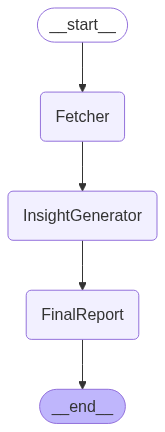

In [46]:
from IPython.display import display, Image, Markdown

display(Image(graph.get_graph().draw_mermaid_png()))

In [47]:
# Run single example
example_customer_id = "CUST_005"
initial_state = {"customer_id": example_customer_id, "customer_data": {}, "insights": ""}
_ = graph.invoke(initial_state)

# Run batch example
batch_ids = [f"CUST_{i:03d}" for i in range(5)]
analyze_batch(batch_ids)

# Generate visualization
generate_visualizations()

# Feature vs SHAP plots with LLM summaries
feature_vs_shap_scatter_summary()

# Summarize segment-level insights
summarize_segments()


=== CUSTOMER INSIGHT REPORT ===
Customer ID: CUST_005
Based on the provided KPI values, SHAP values, and scores for customer CUST_005, here's a natural language summary explaining why the customer's experience score is the way it is:

The customer's experience score is 1.19, which is relatively low. Breaking down the scores, we see that the capacity subscore is 9.73, which is high, but the main score is low. This suggests that the customer's experience is being dragged down by some underlying issues.

Looking at the KPI values, we see that the RSRP (Reference Signal Received Power) is 49.23, which is relatively low. This indicates that the customer is experiencing some level of signal degradation. The SINR (Signal-to-Interference-plus-Noise Ratio) is 53.41, which is relatively high, indicating that the customer is experiencing a good signal quality.

The SHAP values provide more insight into the contribution of each KPI to the overall score. We see that the SHAP value for RSRP is 2.77